## Load cleaned dataset
This notebook starts by loading the clean merged dataset made earlier.  
The purpose of this notebook is to explore the data before feature engineering and modelli .

By first looking at the shape and first rows of the dataset, we get a quick overview of how many observations and columns are available.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

data = pd.read_csv("merged_clean_7years.csv")

print(data.shape)
data.head()

C:\Users\tuvap\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\tuvap\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (
C:\Users\tuvap\AppData\Local\Temp\ipykernel_54548\3092711107.py:5: DtypeWarning: Columns (0: Rutenr) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("merged_clean_7years.csv")


(653213, 56)


,År,Månednr,Ukenr,Dato,Ukedag,Selskapnr,Selskapnavn,Kundekategori_kd,Kundenr,Postnummer,...,Skannet inn på bil %,Skannet ut av bil %,Drivstofftype,Gyldig regnr flg,Ressursnavn (bil),Temperatur på bil (frys),Temperatur på bil (kjøl),KJEDESTYRING,FLESLAND_KATEGORI,delivery_delay_minutes
0,2019,1.0,1.0,2019-01-02,Onsdag,64.0,ASKO ROGALAND AS,1,347369.0,5531.0,...,1.0,1.00,DIESEL,Ja,SD83867,NaN,NaN,NaN,Eksterne grossister,1.833333
1,2019,1.0,1.0,2019-01-03,Torsdag,64.0,ASKO ROGALAND AS,1,347369.0,5531.0,...,1.0,1.00,DIESEL,Ja,RK63822,-20.0,3.0,NaN,Eksterne grossister,-6.750000
2,2019,1.0,1.0,2019-01-02,Onsdag,64.0,ASKO ROGALAND AS,1,356220.0,5528.0,...,1.0,1.00,DIESEL,Ja,RK67397,NaN,NaN,NaN,Eksterne grossister,-4.700000
3,2019,1.0,1.0,2019-01-02,Onsdag,64.0,ASKO ROGALAND AS,1,359158.0,4070.0,...,1.0,1.00,DIESEL,Ja,RK42734,-20.0,3.0,NaN,Eksterne grossister,17.566667
4,2019,1.0,1.0,2019-01-03,Torsdag,64.0,ASKO ROGALAND AS,1,359158.0,4070.0,...,1.0,0.96,DIESEL,Ja,RK60912,-20.0,2.0,NaN,Eksterne grossister,-10.416667


## Prepare date information

The date column is converted to datetime format so it can be used fed analysi  
A separate year column is also created. This makes it easier to compare delivery patterns and route activity across different years.

In [5]:
data["Dato"] = pd.to_datetime(data["Dato"], errors="coerce")
data["year"] = data["Dato"].dt.year

## Check column types

The data types are checked to make sure the columns have the expected format  
This is importahere nt before plotting or groupianythe data, because incorrect data types can lead to wrong calculations other or errors.

In [6]:
data.dtypes

År                                                                       int64
Månednr                                                                float64
Ukenr                                                                  float64
Dato                                                            datetime64[us]
Ukedag                                                                     str
Selskapnr                                                              float64
Selskapnavn                                                                str
Kundekategori_kd                                                         int64
Kundenr                                                                float64
Postnummer                                                             float64
Fylke                                                                      str
Rutenr                                                                  object
Parent Skift ID                                     

## Number of Unique Routes per Year
The number of unique routes is calculated for each year to see how route activity changes over time. This helps show whether the delivery network is stable during the study period. The results show large variation in active routes between years. Therefore r Rou e-level analysiised less suitab, and t The analysis instead continsed at customer levee.e.ime.on.

In [7]:
routesPerYear = data.groupby("year")["Rutenr"].nunique().reset_index(name="uniqueRoutes")
routesPerYear

,year,uniqueRoutes
0,2019,779
1,2020,659
2,2021,703
3,2022,763
4,2023,348
5,2024,460
6,2025,347


## Overlap between 2019 and 2025

The routes from 2019 and 2025 are compared to see how many route numbers appear in both year  
This helps indicate whether the same route structure has continued over time, or whether routes have changed during the peri .

This is useful before modelling because a changing route structure can make historical patterns harder to learn.

In [8]:
routes2019 = set(data[data["year"] == 2019]["Rutenr"])
routes2025 = set(data[data["year"] == 2025]["Rutenr"])

overlap = routes2019.intersection(routes2025)

print("Routes in 2019:", len(routes2019))
print("Routes in 2025:", len(routes2025))
print("Routes in both years:", len(overlap))

Routes in 2019: 779
Routes in 2025: 347
Routes in both years: 216


## Distribution of delivery times

A histogram is used to show how actual delivery times are distribute  
This helps identify the most common delivery durations and whether there aor extreme valu .

This is important because the target variable in the forecasting model is delivery time.

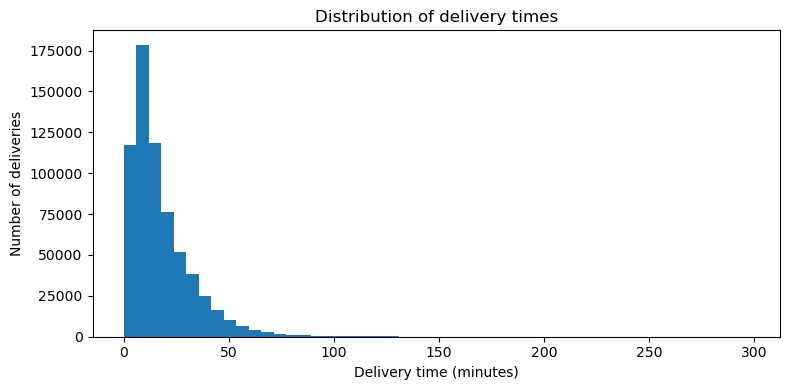

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(data["Leveringstid (min)"], bins=50)
plt.xlabel("Delivery time (minutes)")
plt.ylabel("Number of deliveries")
plt.title("Distribution of delivery times")
plt.tight_layout()
plt.show()

## Average delivery time over time

The average delivery time is calculated for each date and plotted across the full time perio  
This makes it possible to see whether delivery times are stable, increasing, decreasing or affected by periods with unusual behavio .

This is useful for understanding whether the model needs to lany earn time-related patt The figure below shows that average delivery time is quite stable over the full time period. Most observations are between 15 and 25 minutes, which suggests normal operations are stable. 
A small decrease can be seen from around 202and forwardds. This shows that time patterns may be useful for the mode 

Seveclear peaksikes are also visible. These may be cause  or unusual operating conditi Tall, the r overall sults show stable delivery times with some variation and some ou as expectedtliers. This supports the use of calendar features and careful handling of unusual observations.tions.fully.delling.erns.

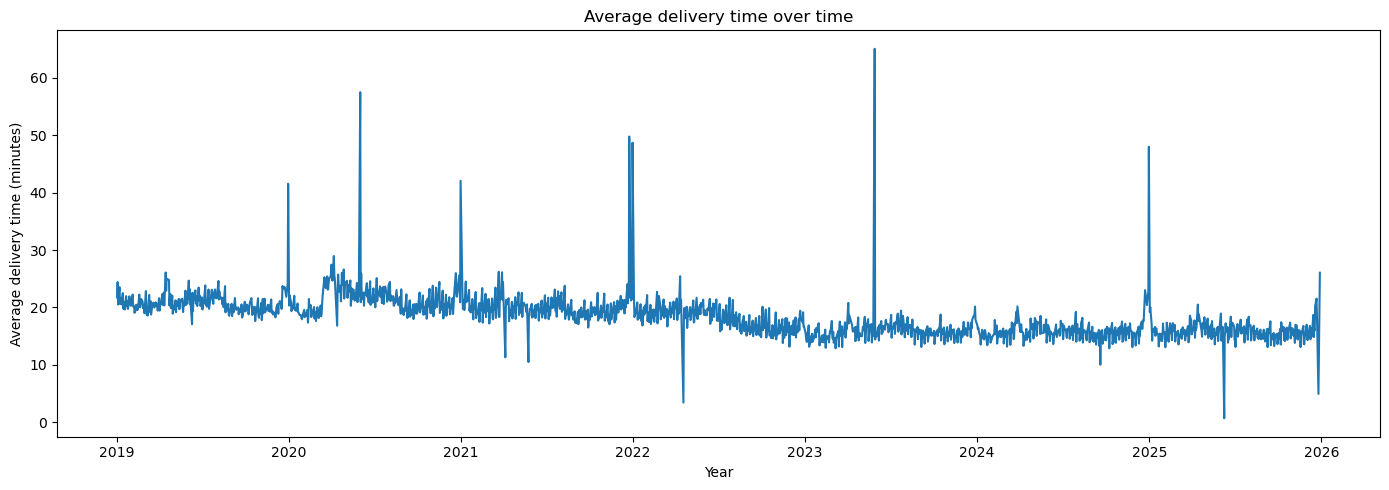

In [10]:
dailyMean = data.groupby("Dato")["Leveringstid (min)"].mean()

plt.figure(figsize=(14, 5))
plt.plot(dailyMean.index, dailyMean.values)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.xlabel("Year")
plt.ylabel("Average delivery time (minutes)")
plt.title("Average delivery time over time")
plt.tight_layout()
plt.show()

## Deliveries per customer

The number of deliveries per customer is calculated to understand how often customers appear in the datase  
This is important because the forecasting model uses historical customer behaviour, and customers with many deliveries provide more information than customers with very fdeliveriesons.

In [11]:
deliveriesPerCustomer = data.groupby("Kundenr").size()
deliveriesPerCustomer.describe()

count    2912.000000
mean      224.317651
std       385.483957
min         1.000000
25%        11.000000
50%        64.000000
75%       252.250000
max      2225.000000
dtype: float64

## Distribution of Deliveries per Customer

The histogram shows how deliveries are distributed across customers. This helps show whether the dataset is balanced across customers or whether a small number of customers have many deliveries. This is relevant because uneven customer history can affect how well the model learns customer pattern 

As seen in the figure below, most customers have relatively few deliveries, while a smaller number of customers have many deliveries. This is normal, but it creates a r ght-skewed distribution. The results support the use of cust mer-level feat,ures and show that some customers have more historical data than others.ers.

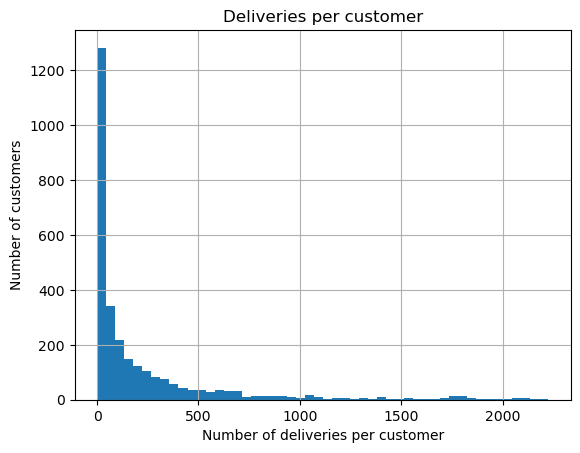

In [12]:
deliveriesPerCustomer.hist(bins=50)

plt.xlabel("Number of deliveries per customer")
plt.ylabel("Number of customers")
plt.title("Deliveries per customer")
plt.show()

## Delivery time compared with delivered volume

This scatter plot compares delivered volume with actual delivery time. The goal is to see whether larger deliveries generally take longer to complete. This relationship is important because volume will later be used in the scenario analysis, and can influence service time and vehicle load. 

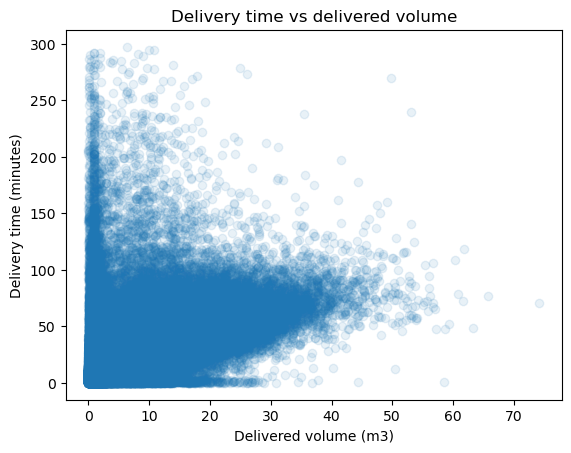

In [13]:
plt.scatter(data["Levert volum (m3)"], data["Leveringstid (min)"], alpha=0.1)

plt.xlabel("Delivered volume (m3)")
plt.ylabel("Delivery time (minutes)")
plt.title("Delivery time vs delivered volume")

plt.show()

## Average Delivery Time by Weekday
Average delivery time is compared across weekdays. This helps show whether delivery time differs between Monday, Tuesday, Wednesday, Thursday and Friday. Weekday patterns can be useful in forecasting because operating conditions may vary during the week. 
Looking at the figure, the differences between weekdays are relatively small, as expected. Monday has the highest average delivery time, which ialso s expected because this is the busiest day at ASKO. Tuesday has the lowest. The other weekdays are at a similar leve 

This suggests that weekday may be a useful feature in the model, but not one of the strongest factors alone.one.

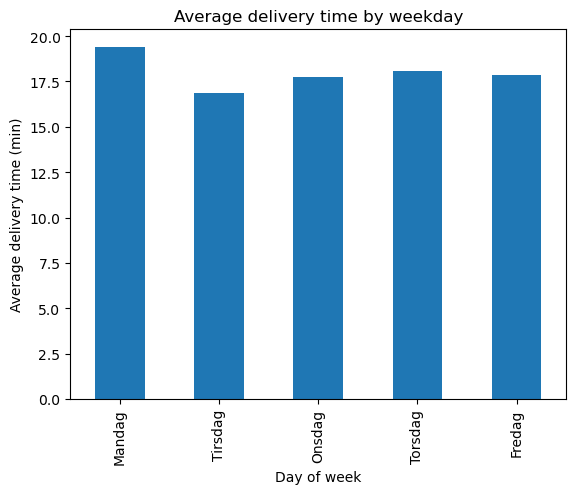

In [16]:
weekDays = ["Mandag", "Tirsdag", "Onsdag", "Torsdag", "Fredag"]
avgByDay = data.groupby("Ukedag")["Leveringstid (min)"].mean().reindex(weekDays)
avgByDay.plot(kind="bar")

plt.xlabel("Day of week")
plt.ylabel("Average delivery time (min)")
plt.title("Average delivery time by weekday")
plt.show()

In [15]:
import json

with open("2 EDA.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        print("\n" + "="*70)
        print(f"CELL {i}")
        print("="*70)
        print("".join(cell["source"]))



CELL 1
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

data = pd.read_csv("merged_clean_7years.csv")

print(data.shape)
data.head()

CELL 3
data["Dato"] = pd.to_datetime(data["Dato"], errors="coerce")
data["year"] = data["Dato"].dt.year

CELL 5
data.dtypes

CELL 7
routesPerYear = data.groupby("year")["Rutenr"].nunique().reset_index(name="uniqueRoutes")
routesPerYear

CELL 9
routes2019 = set(data[data["year"] == 2019]["Rutenr"])
routes2025 = set(data[data["year"] == 2025]["Rutenr"])

overlap = routes2019.intersection(routes2025)

print("Routes in 2019:", len(routes2019))
print("Routes in 2025:", len(routes2025))
print("Routes in both years:", len(overlap))

CELL 11
plt.figure(figsize=(8, 4))
plt.hist(data["Leveringstid (min)"], bins=50)
plt.xlabel("Delivery time (minutes)")
plt.ylabel("Number of deliveries")
plt.title("Distribution of delivery times")
plt.tight_layout()
plt.show()

CELL 13
dailyMean = data.groupby("Dato")["Leveringstid (min)"].mea